# Default of Credit Card Clients: Multivariate Analysis

this notebook uses the datasets generated by `gen_multi.ipynb`. run that notebook first if the CSV files in `data/` are missing.

In [1]:
import pandas as pd
import numpy as np

from missingfcup import MissingData
from missingfcup import Panel

from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

import plotly.io as pio
pio.renderers.default = "png"

In [2]:
df_mcar = pd.read_csv("data/mcar_multi.csv")
df_mar  = pd.read_csv("data/mar_multi.csv")
df_mnar = pd.read_csv("data/mnar_multi.csv")

In [3]:
md_mcar = MissingData(df_mcar)
md_mar  = MissingData(df_mar.drop(columns=["target"], errors="ignore"))
md_mnar = MissingData(df_mnar.drop(columns=["target"], errors="ignore"))

## Exploratory Discovery

these first plots validate that each generator introduced missingness at the expected scale.

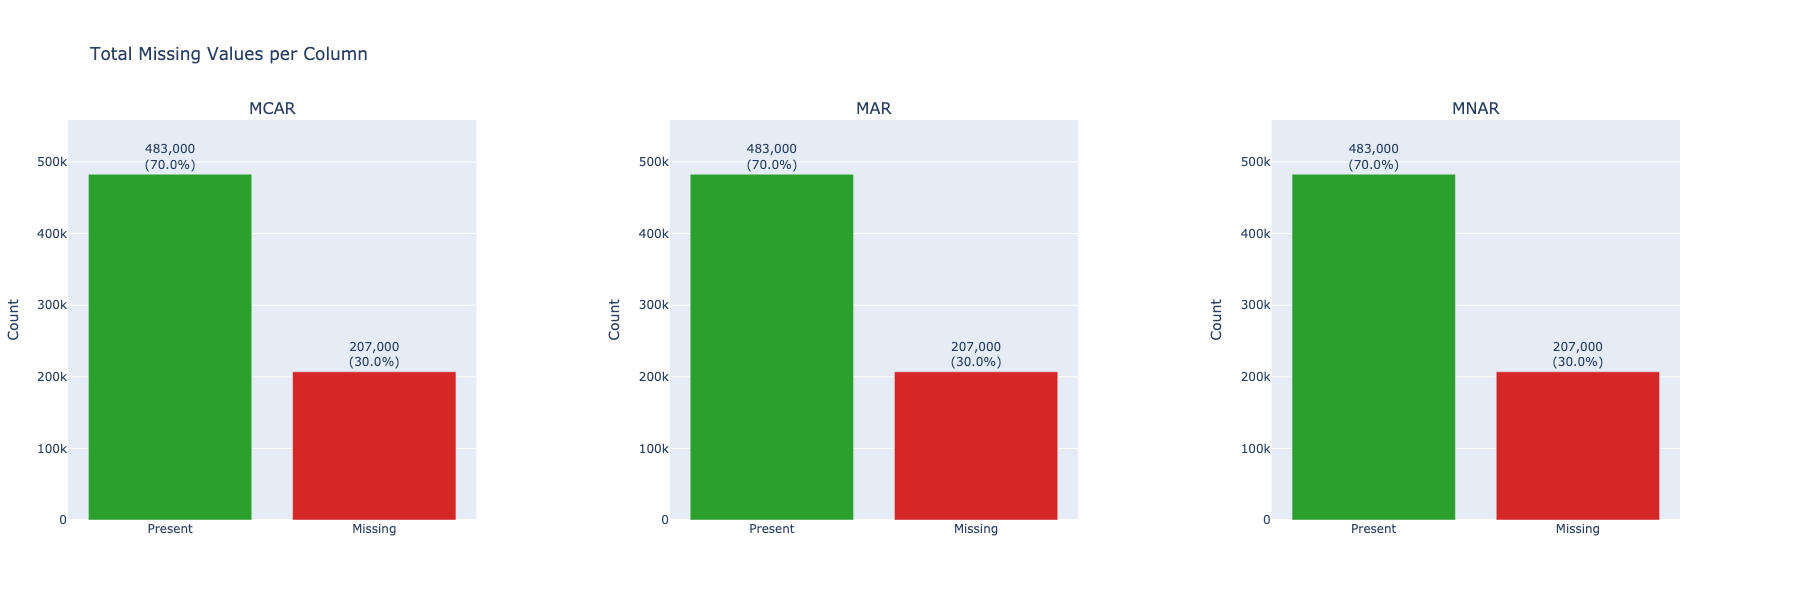

In [4]:
panel = Panel(
    plots=[
        md_mcar.totals(title="MCAR"),
        md_mar.totals(title="MAR"),
        md_mnar.totals(title="MNAR"),
    ],
    title="Total Missing Values per Column",
    width=1800,
    height=600,
)

panel.show()
panel.save()

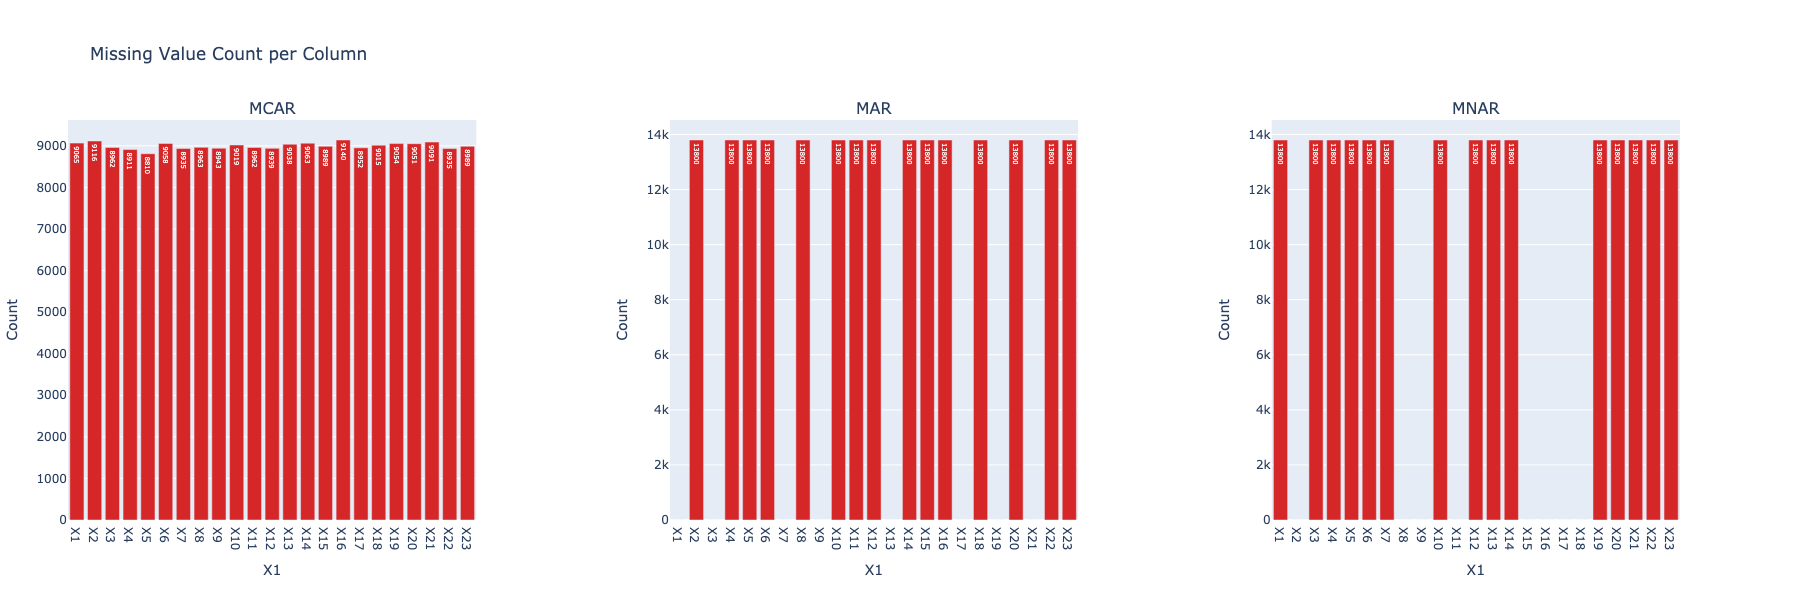

In [5]:
panel = Panel(
    plots=[
        md_mcar.bar(title="MCAR"),
        md_mar.bar(title="MAR"),
        md_mnar.bar(title="MNAR"),
    ],
    title="Missing Value Count per Column",
    width=1800,
    height=600,
)

panel.show()
panel.save()

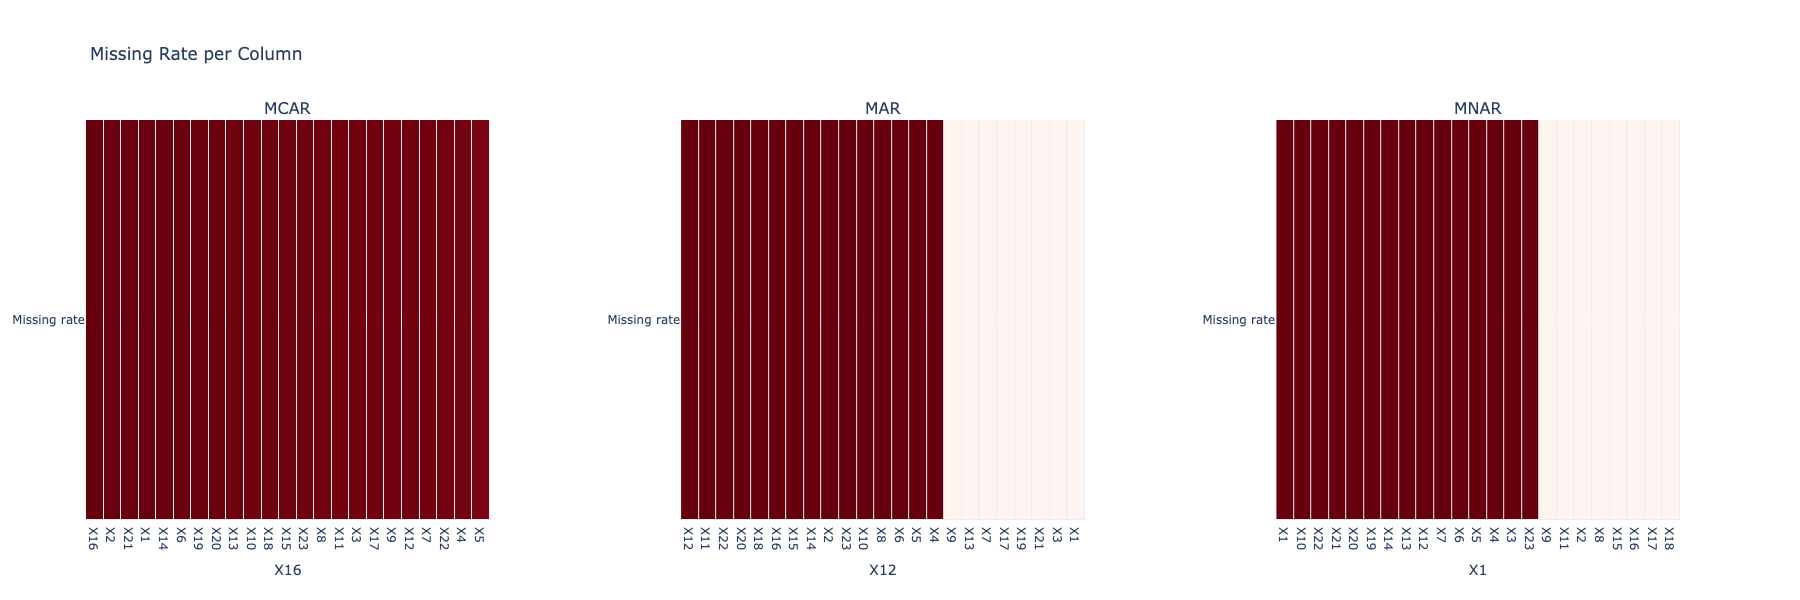

In [6]:
panel = Panel(
    plots=[
        md_mcar.rate(title="MCAR"),
        md_mar.rate(title="MAR"),
        md_mnar.rate(title="MNAR"),
    ],
    title="Missing Rate per Column",
    width=1800,
    height=600,
)

panel.show()
panel.save()

MCAR spreads missing values uniformly across all 23 columns (~30% each). MAR and MNAR both show a binary pattern: 15 columns have exactly 13800 missing values (~46%) while the remaining 8 have none.

the intersection and venn plots show which columns tend to be missing at the same time.

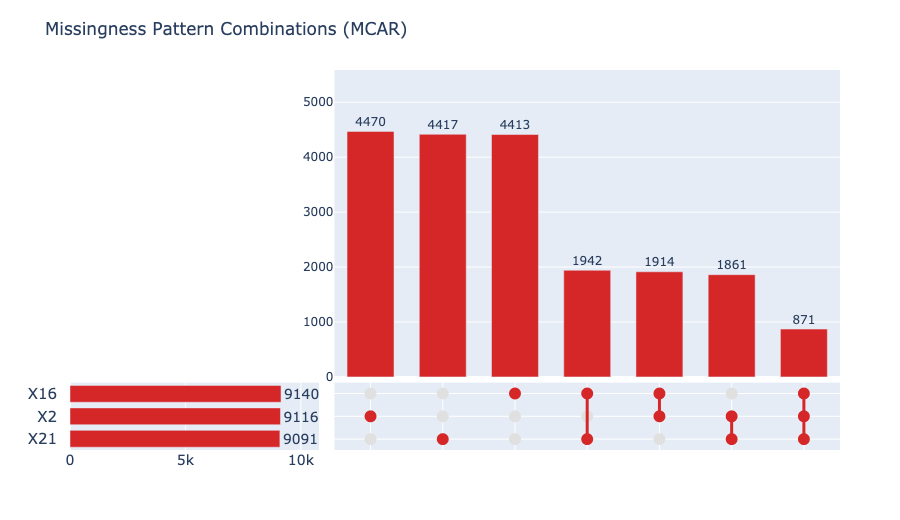

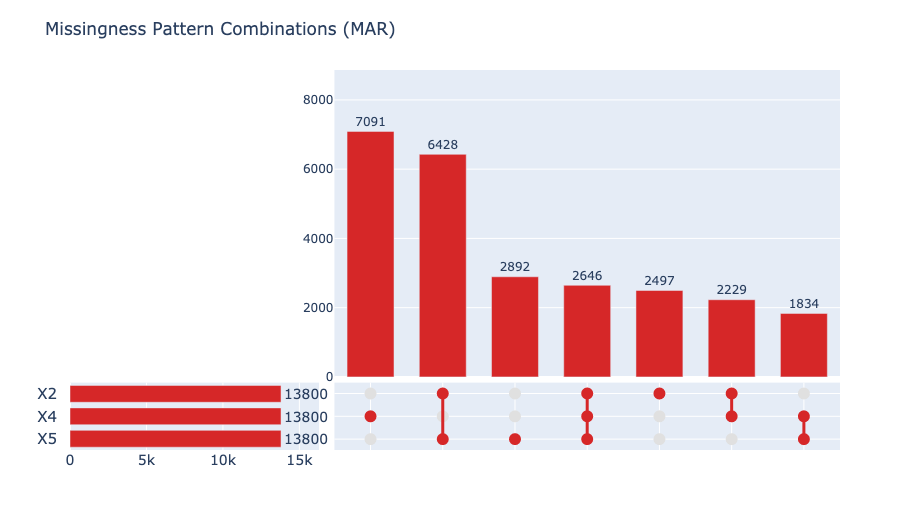

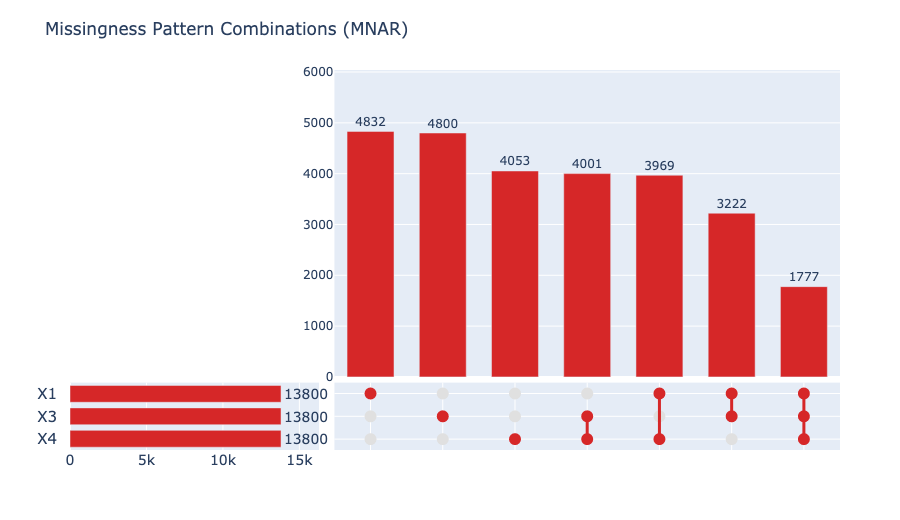

In [7]:
plot_mcar = md_mcar.upset(title="Missingness Pattern Combinations (MCAR)")
plot_mar  = md_mar.upset(title="Missingness Pattern Combinations (MAR)")
plot_mnar = md_mnar.upset(title="Missingness Pattern Combinations (MNAR)")

plot_mcar.show()
plot_mcar.save()

plot_mar.show()
plot_mar.save()

plot_mnar.show()
plot_mnar.save()

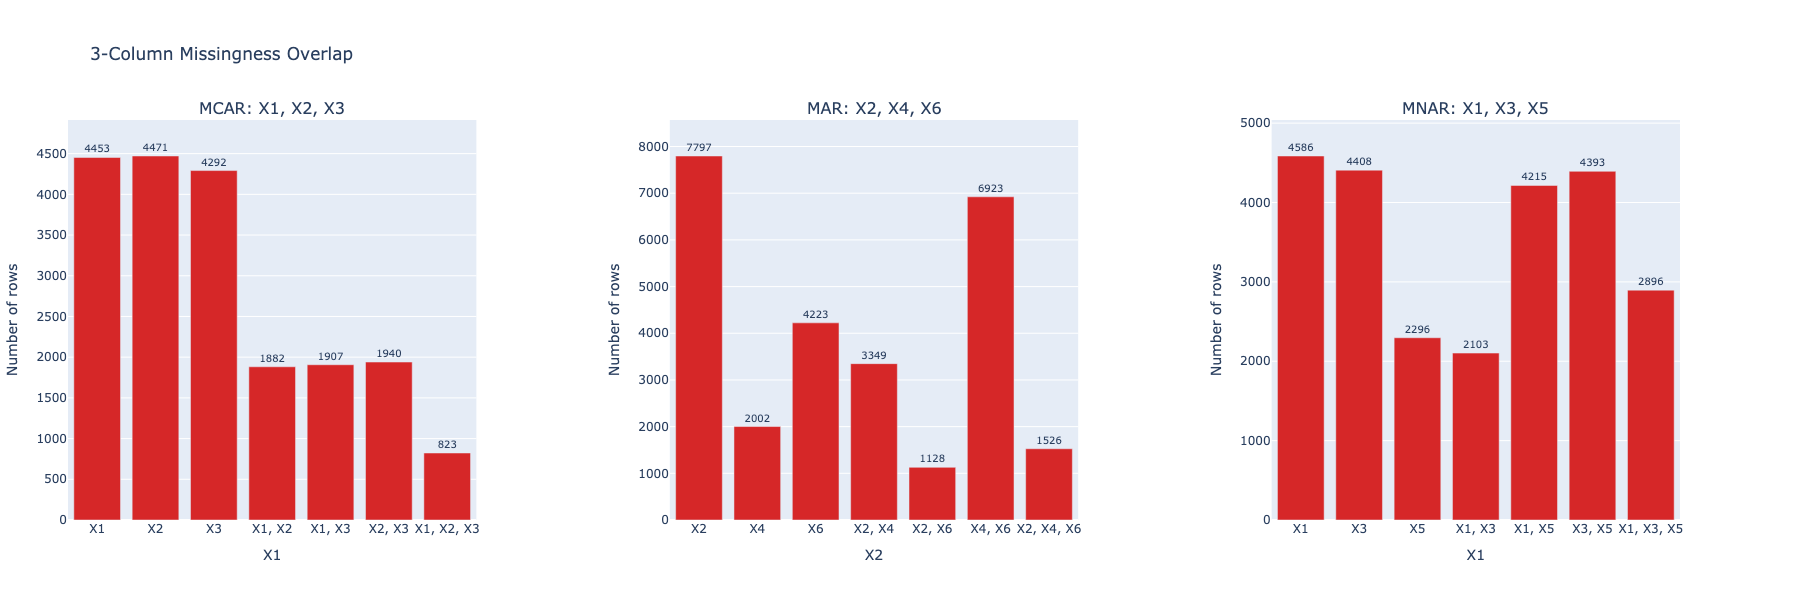

In [8]:
panel = Panel(
    plots=[
        md_mcar.venn(selected_columns=["X1", "X2", "X3"], title="MCAR: X1, X2, X3"),
        md_mar.venn(selected_columns=["X2", "X4", "X6"], title="MAR: X2, X4, X6"),
        md_mnar.venn(selected_columns=["X1", "X3", "X5"], title="MNAR: X1, X3, X5"),
    ],
    title="3-Column Missingness Overlap",
    width=1800,
    height=600,
)

panel.show()
panel.save()

## Mechanism Discovery

we now look for structural patterns in the missingness using heatmaps, correlation matrices, dendrograms, and value-missingness correlations.

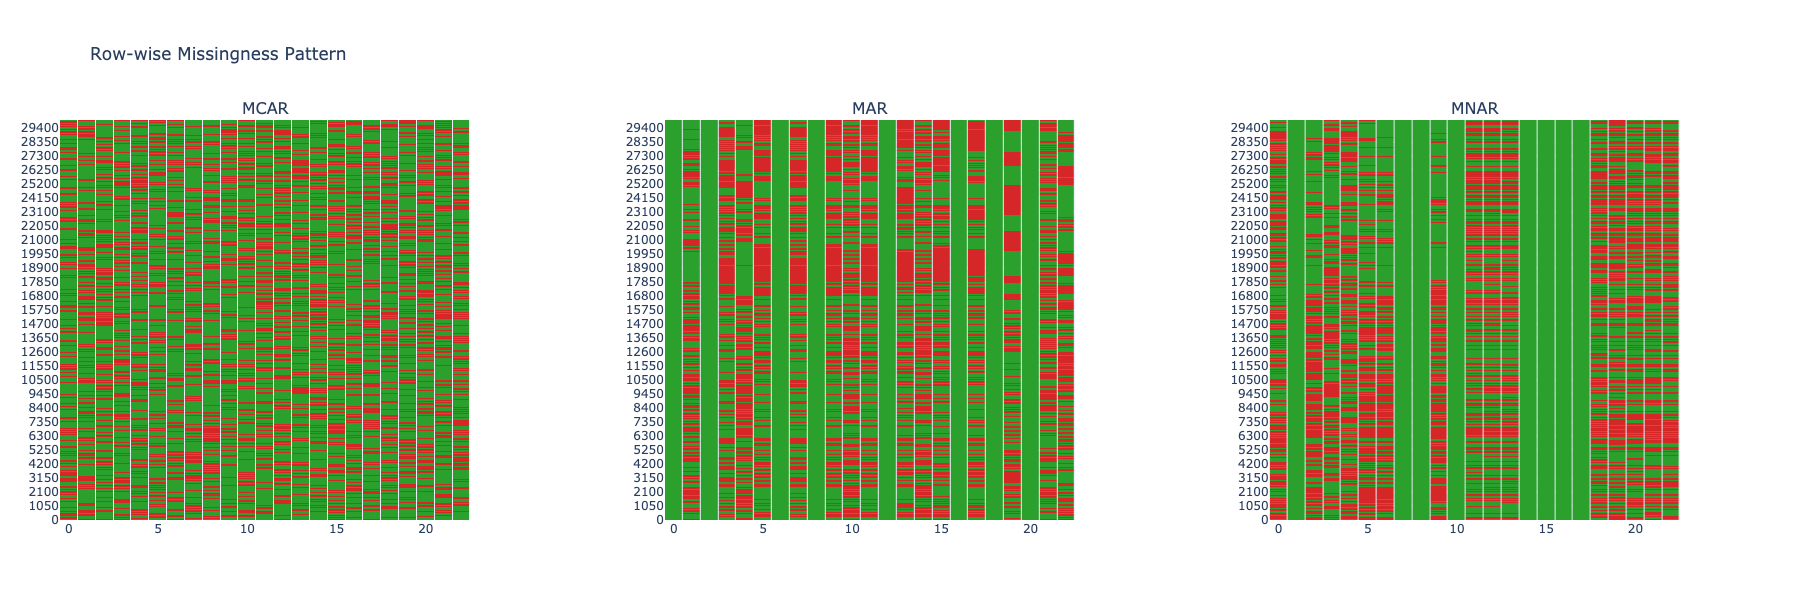

In [9]:
panel = Panel(
    plots=[
        md_mcar.matrix(title="MCAR"),
        md_mar.matrix(title="MAR"),
        md_mnar.matrix(title="MNAR"),
    ],
    title="Row-wise Missingness Pattern",
    width=1800,
    height=600,
)

panel.show()
panel.save(save_individual=True)

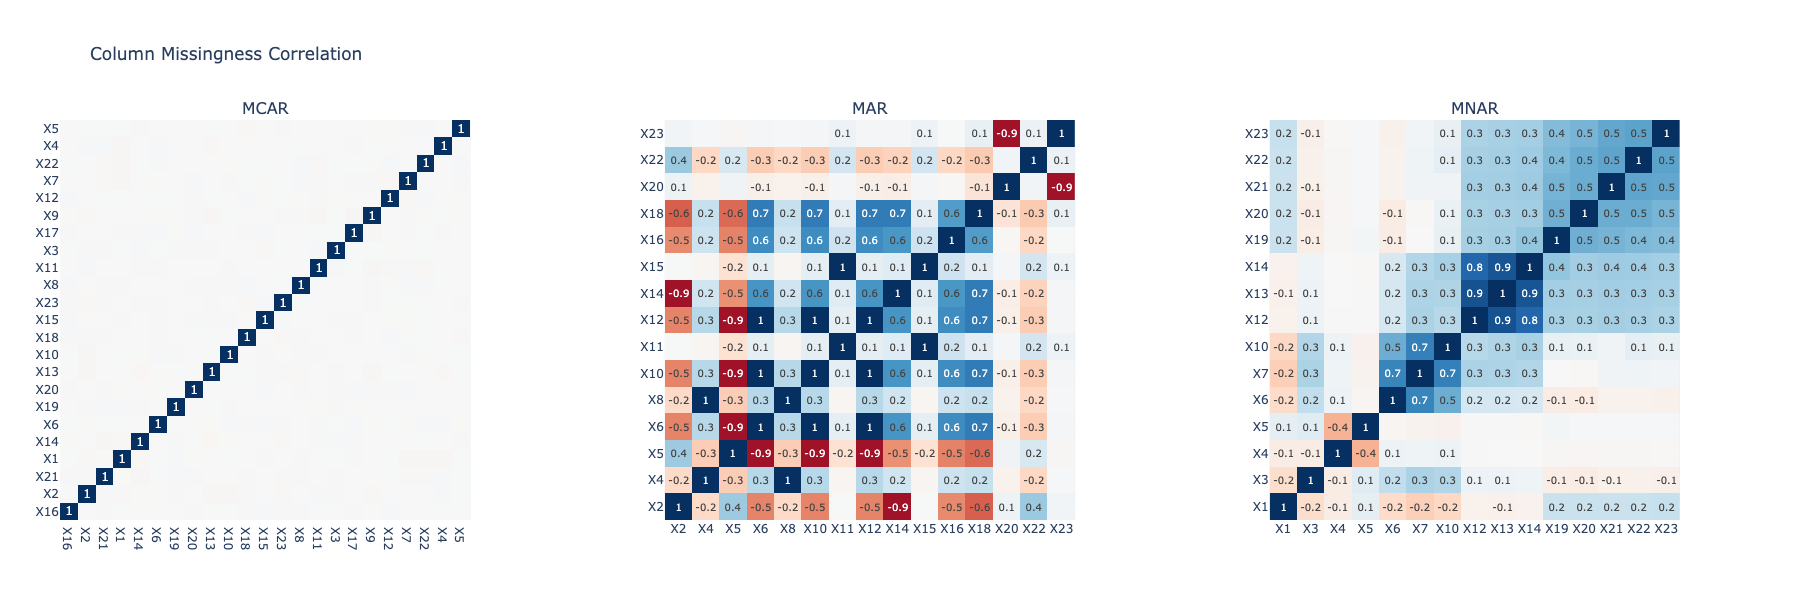

In [10]:
panel = Panel(
    plots=[
        md_mcar.heatmap(title="MCAR"),
        md_mar.heatmap(title="MAR", drop_constant_columns=True),
        md_mnar.heatmap(title="MNAR", drop_constant_columns=True),
    ],
    title="Column Missingness Correlation",
    width=1800,
    height=600,
)

panel.show()
panel.save(save_individual=True)

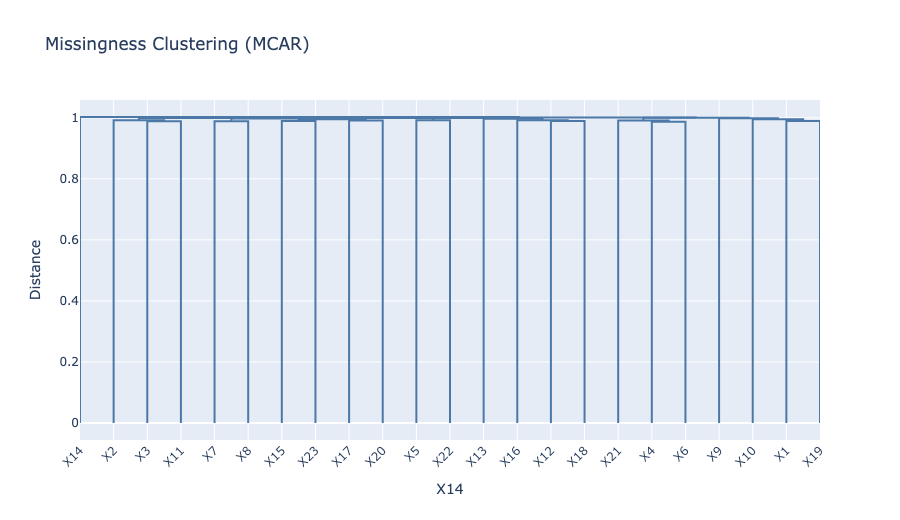

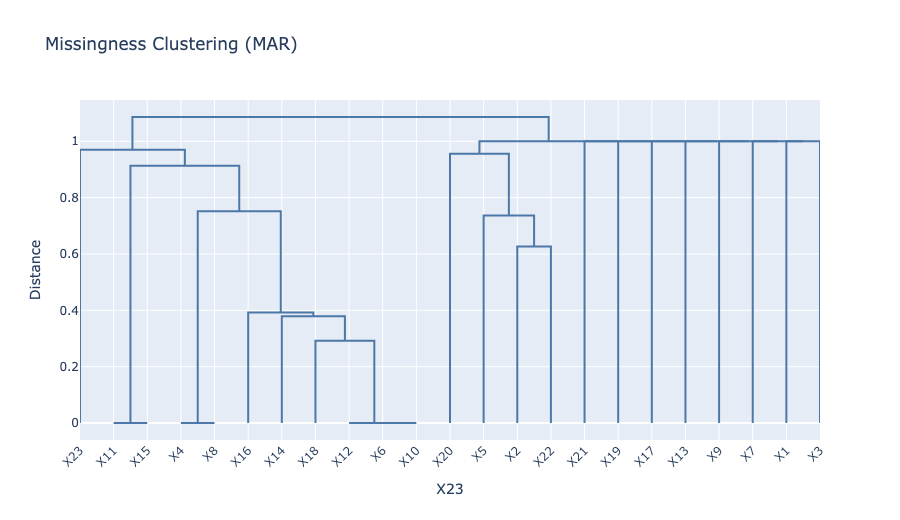

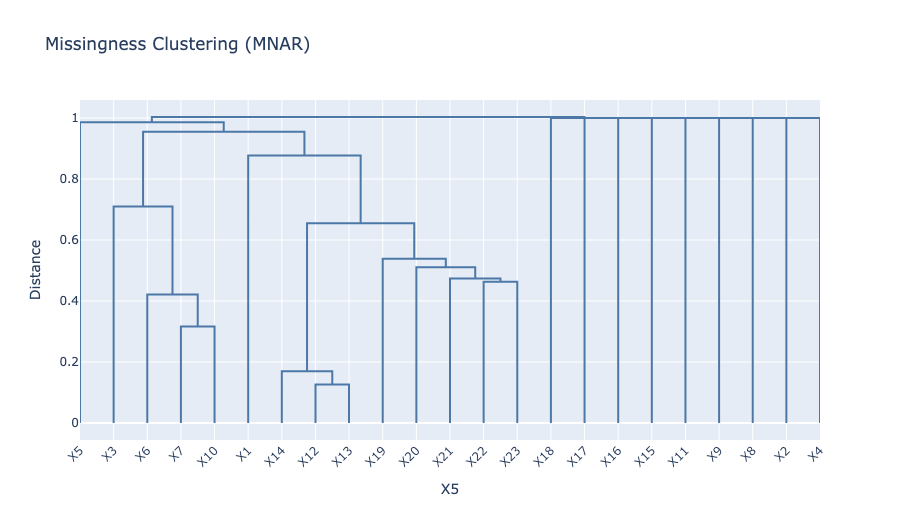

In [11]:
plot_mcar = md_mcar.dendrogram(title="Missingness Clustering (MCAR)")
plot_mar  = md_mar.dendrogram(title="Missingness Clustering (MAR)")
plot_mnar = md_mnar.dendrogram(title="Missingness Clustering (MNAR)")

plot_mcar.show()
plot_mcar.save()

plot_mar.show()
plot_mar.save()

plot_mnar.show()
plot_mnar.save()

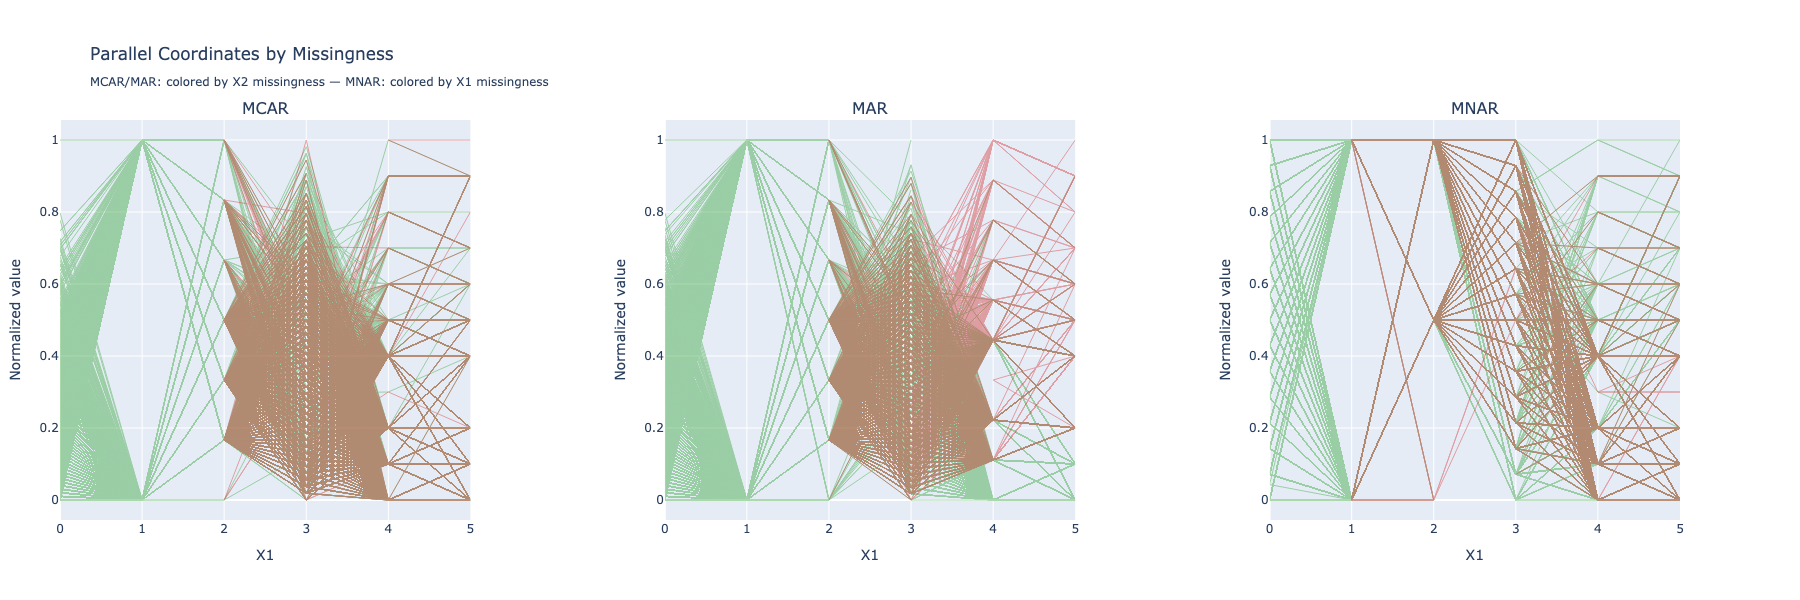

In [12]:
plot_mcar_pc = md_mcar.parallel_coordinates(
    title="MCAR",
    selected_columns=["X1", "X2", "X3", "X5", "X8", "X9"],
    missingness_color_column="X2",
)
plot_mar_pc = md_mar.parallel_coordinates(
    title="MAR",
    selected_columns=["X1", "X2", "X3", "X5", "X8", "X9"],
    missingness_color_column="X2",
)
plot_mnar_pc = md_mnar.parallel_coordinates(
    title="MNAR",
    selected_columns=["X1", "X2", "X3", "X5", "X8", "X9"],
    missingness_color_column="X1",
)

panel = Panel(
    plots=[plot_mcar_pc, plot_mar_pc, plot_mnar_pc],
    title="Parallel Coordinates by Missingness",
    description="MCAR/MAR: colored by X2 missingness, MNAR: colored by X1 missingness",
    width=1800,
    height=600,
)

panel.show()
panel.save(save_individual=True)

plot_mcar_pc.save()
plot_mar_pc.save()
plot_mnar_pc.save()

in MCAR, the X2-missing lines show no systematic deviation from X2-present lines across any of the six selected variables, confirming random deletion. in MAR, the X2-missing lines (affected partner column) concentrate at lower X1 values, consistent with credit-limit-based row selection by the MAR generator. in MNAR, the coloring switches to X1 missingness (an MNAR-affected column): the X1-missing lines cluster at lower X8 and X9 repayment-status values, an indirect signature that the non-defaulters (who settle payments promptly) were preferentially removed by the unobserved default indicator.

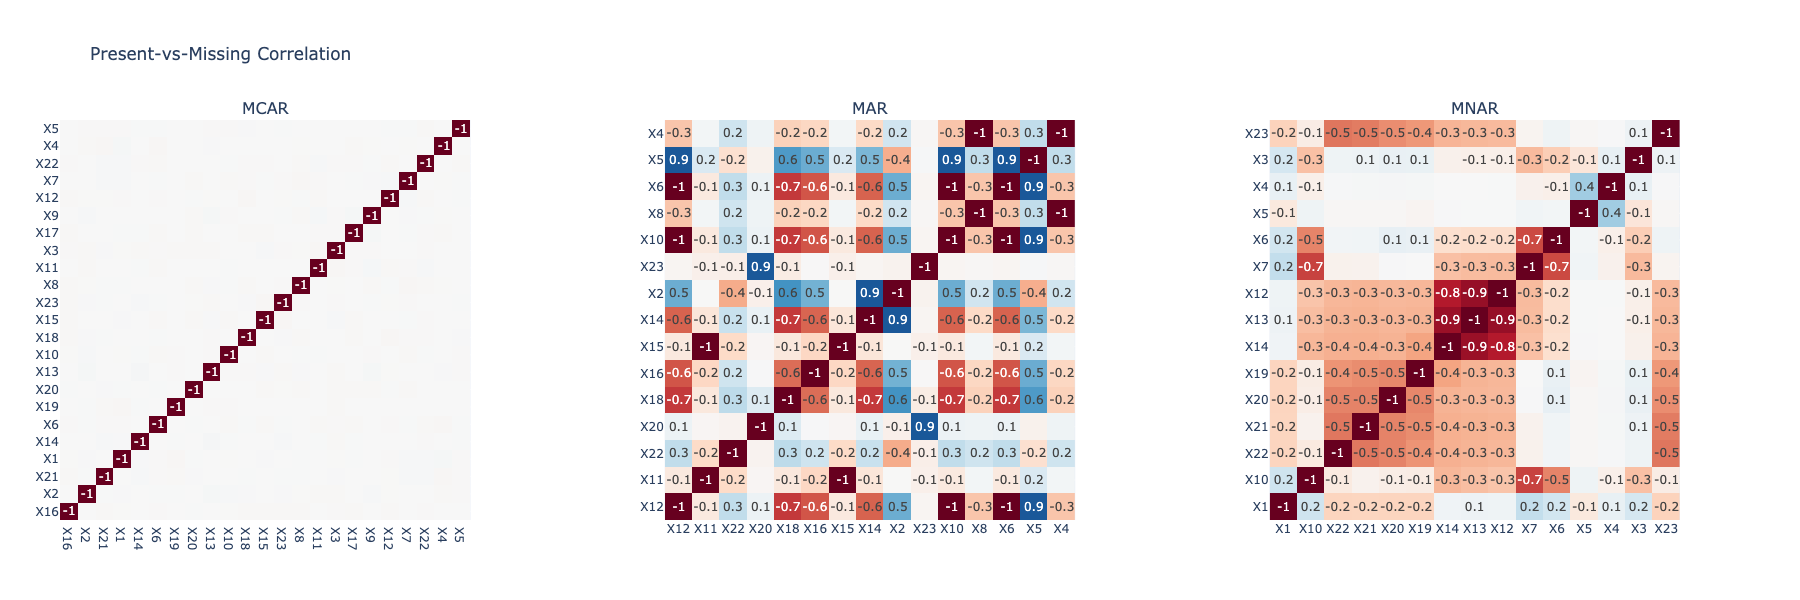

In [13]:
panel = Panel(
    plots=[
        md_mcar.heatmap(kind="predictive", title="MCAR"),
        md_mar.heatmap(kind="predictive", title="MAR", drop_constant_columns=True),
        md_mnar.heatmap(kind="predictive", title="MNAR", drop_constant_columns=True),
    ],
    title="Present-vs-Missing Correlation",
    width=1800,
    height=600,
)

panel.show()
panel.save(save_individual=True)

we now test three driver-partner candidate pairs identified from the predictive heatmap.
MAR drivers (non-affected columns): X1, X3, X7, X9, X13, X17, X19, X21.
MAR partners (affected columns): X2, X4, X5, X6, X8, X10, X11, X12, X14, X15, X16, X18, X20, X22, X23.

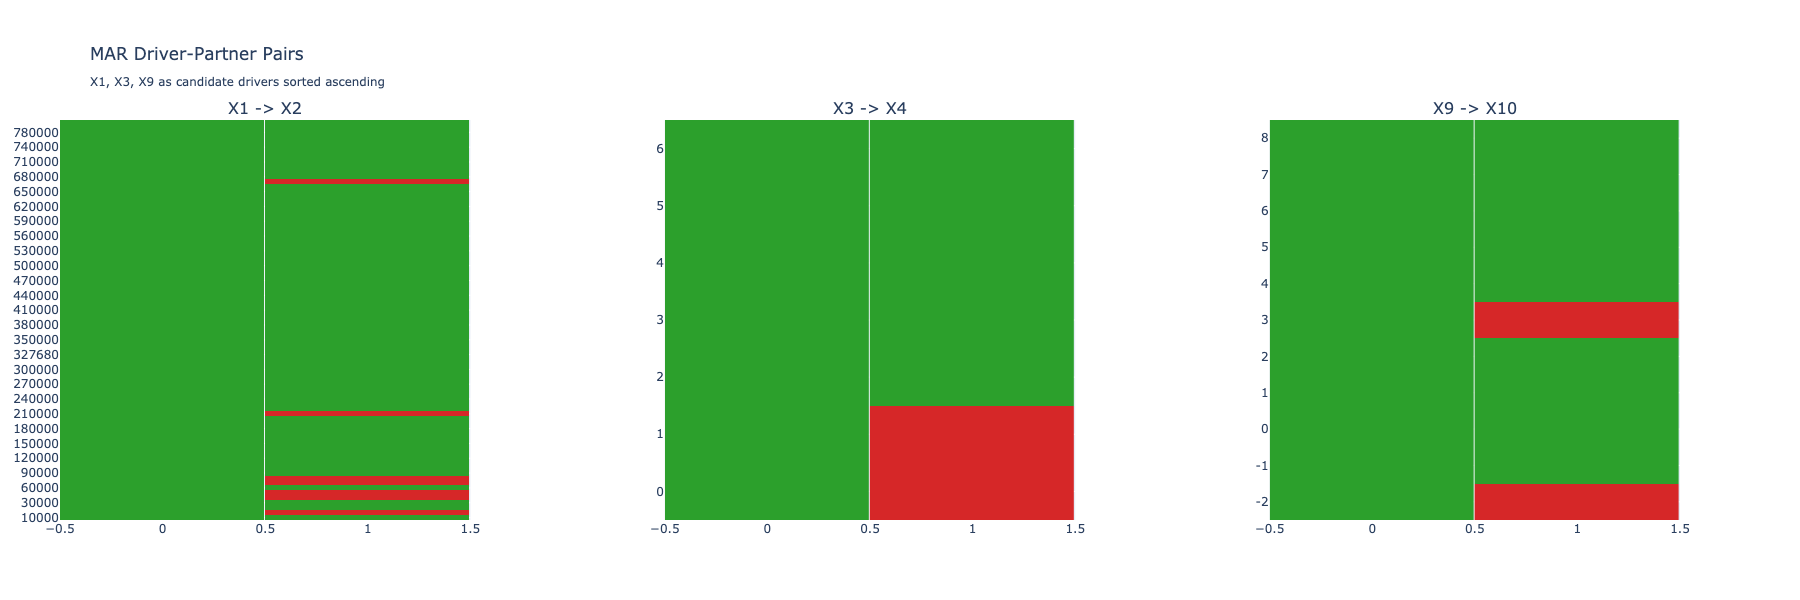

In [14]:
panel = Panel(
    plots=[
        md_mar.matrix(
            title="X1 -> X2",
            selected_columns=["X1", "X2"],
            order_by=[{"axis": "rows", "column": "X1", "ascending": True}],
        ),
        md_mar.matrix(
            title="X3 -> X4",
            selected_columns=["X3", "X4"],
            order_by=[{"axis": "rows", "column": "X3", "ascending": True}],
        ),
        md_mar.matrix(
            title="X9 -> X10",
            selected_columns=["X9", "X10"],
            order_by=[{"axis": "rows", "column": "X9", "ascending": True}],
        ),
    ],
    title="MAR Driver-Partner Pairs",
    description="X1, X3, X9 as candidate drivers sorted ascending",
    width=1800,
    height=600,
)

panel.show()
panel.save(save_individual=True)

for MNAR, the true driver is the unobserved target (default_payment_next_month). we sort by two non-affected proxy columns X8 and X9 (repayment status variables) that may correlate with the target.

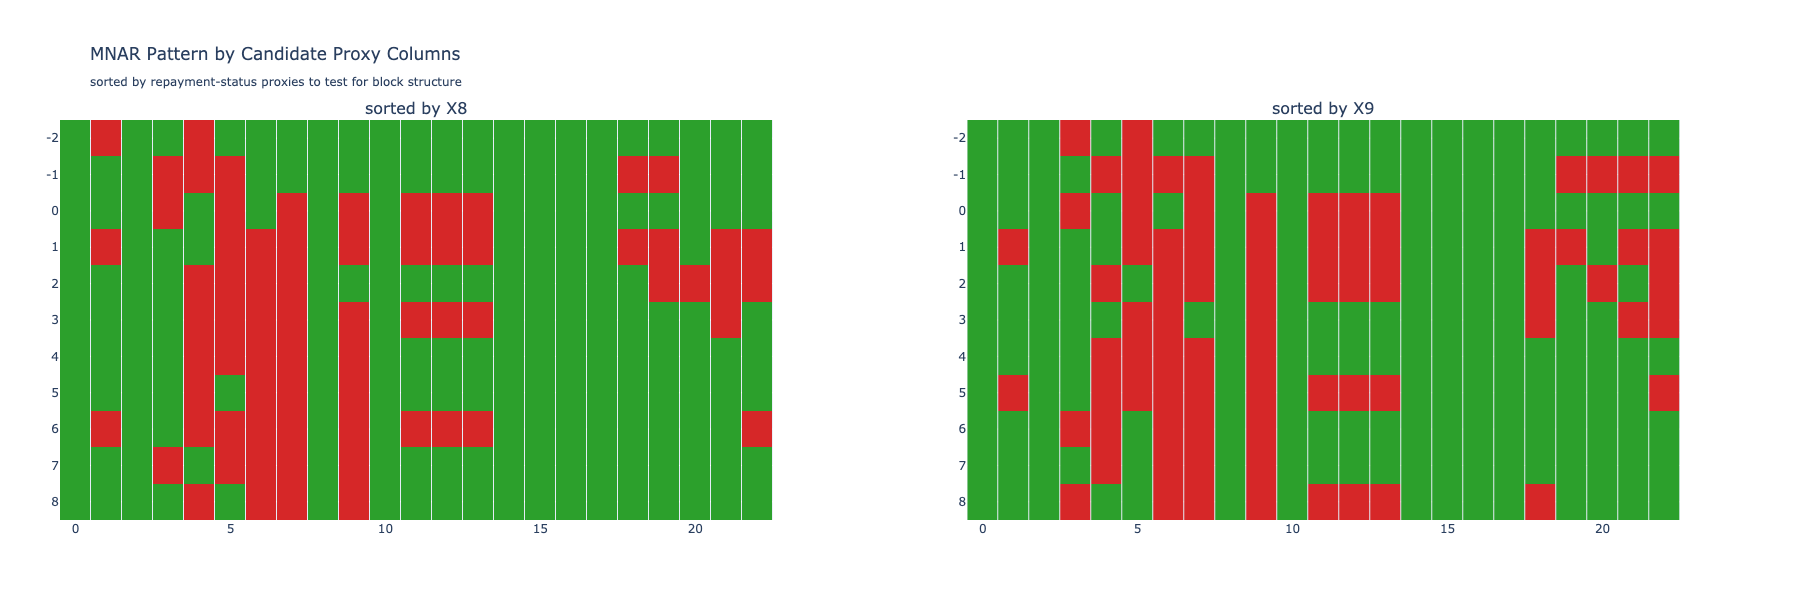

In [15]:
panel = Panel(
    plots=[
        md_mnar.matrix(
            title="sorted by X8",
            order_by=[{"axis": "rows", "column": "X8", "ascending": False}]
        ),
        md_mnar.matrix(
            title="sorted by X9",
            order_by=[{"axis": "rows", "column": "X9", "ascending": False}]
        ),
    ],
    title="MNAR Pattern by Candidate Proxy Columns",
    description="sorted by repayment-status proxies to test for block structure",
    width=1800,
    height=600,
)

panel.show()
panel.save(save_individual=True)

## Comparative Discovery

since missingness was artificially introduced, the original complete dataset is available as ground truth. we use density plots, boxplots, and scatterplots to compare the distributions of observed values between present and missing groups.

to confirm MNAR, we compare observed distributions of proxy variables between MCAR and MNAR. MNAR removed rows where `default_payment_next_month=0` (non-defaulters, the lower-target-value group). non-defaulters may differ in repayment behaviour (X8, X9) from defaulters, so their removal should produce a visible distribution shift.

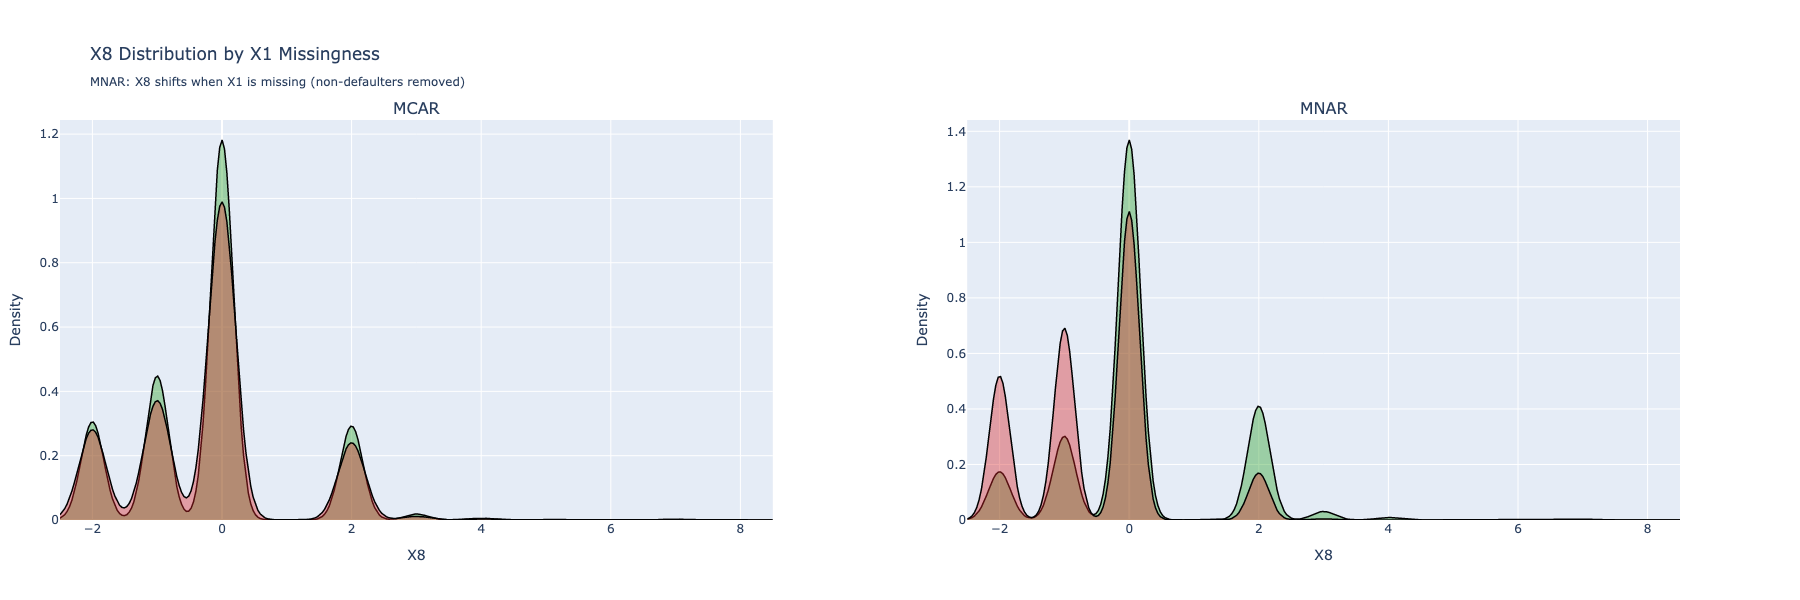

In [16]:
panel = Panel(
    plots=[
        md_mcar.density(x="X8", color_by="X1", title="MCAR"),
        md_mnar.density(x="X8", color_by="X1", title="MNAR"),
    ],
    title="X8 Distribution by X1 Missingness",
    description="MNAR: X8 shifts when X1 is missing (non-defaulters removed)",
    width=1800,
    height=600,
)

panel.show()
panel.save()

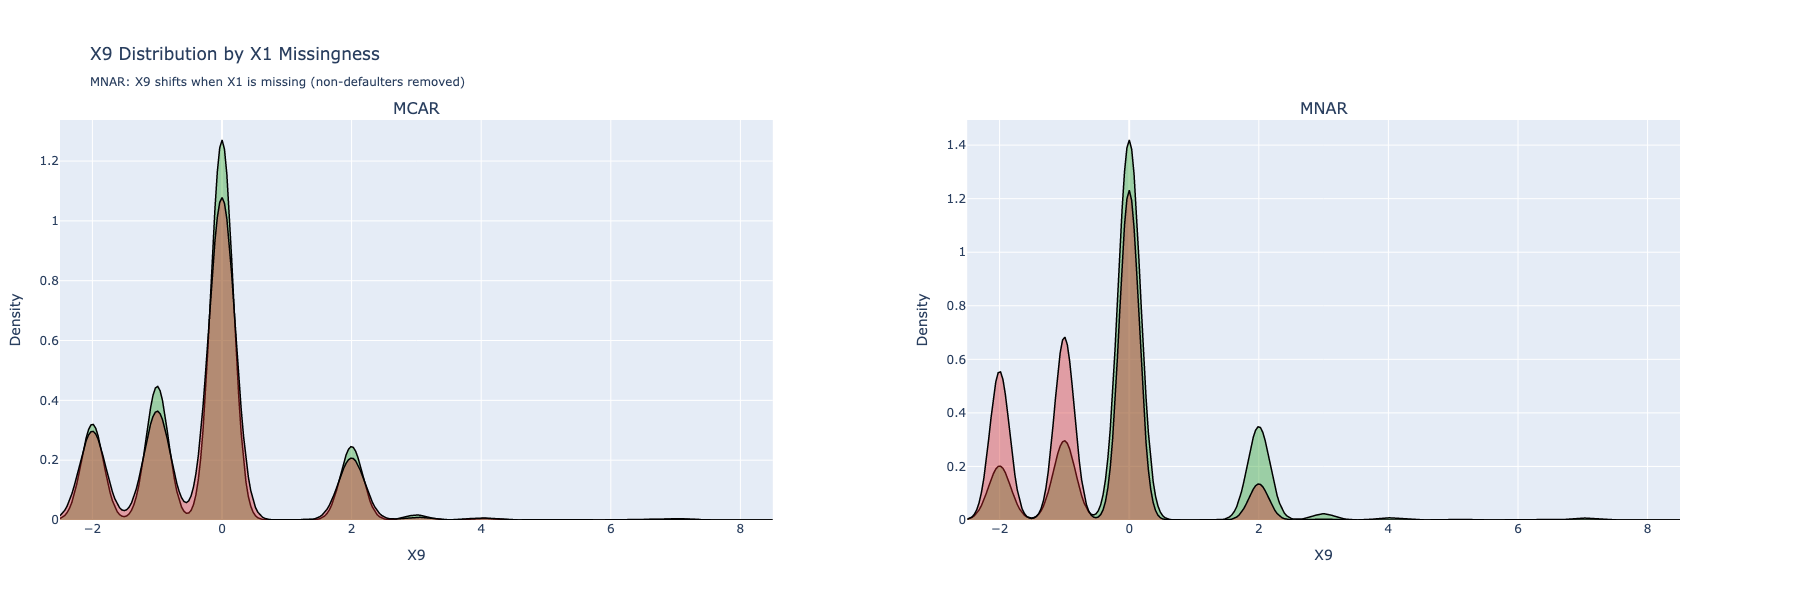

In [17]:
panel = Panel(
    plots=[
        md_mcar.density(x="X9", color_by="X1", title="MCAR"),
        md_mnar.density(x="X9", color_by="X1", title="MNAR"),
    ],
    title="X9 Distribution by X1 Missingness",
    description="MNAR: X9 shifts when X1 is missing (non-defaulters removed)",
    width=1800,
    height=600,
)

panel.show()
panel.save()

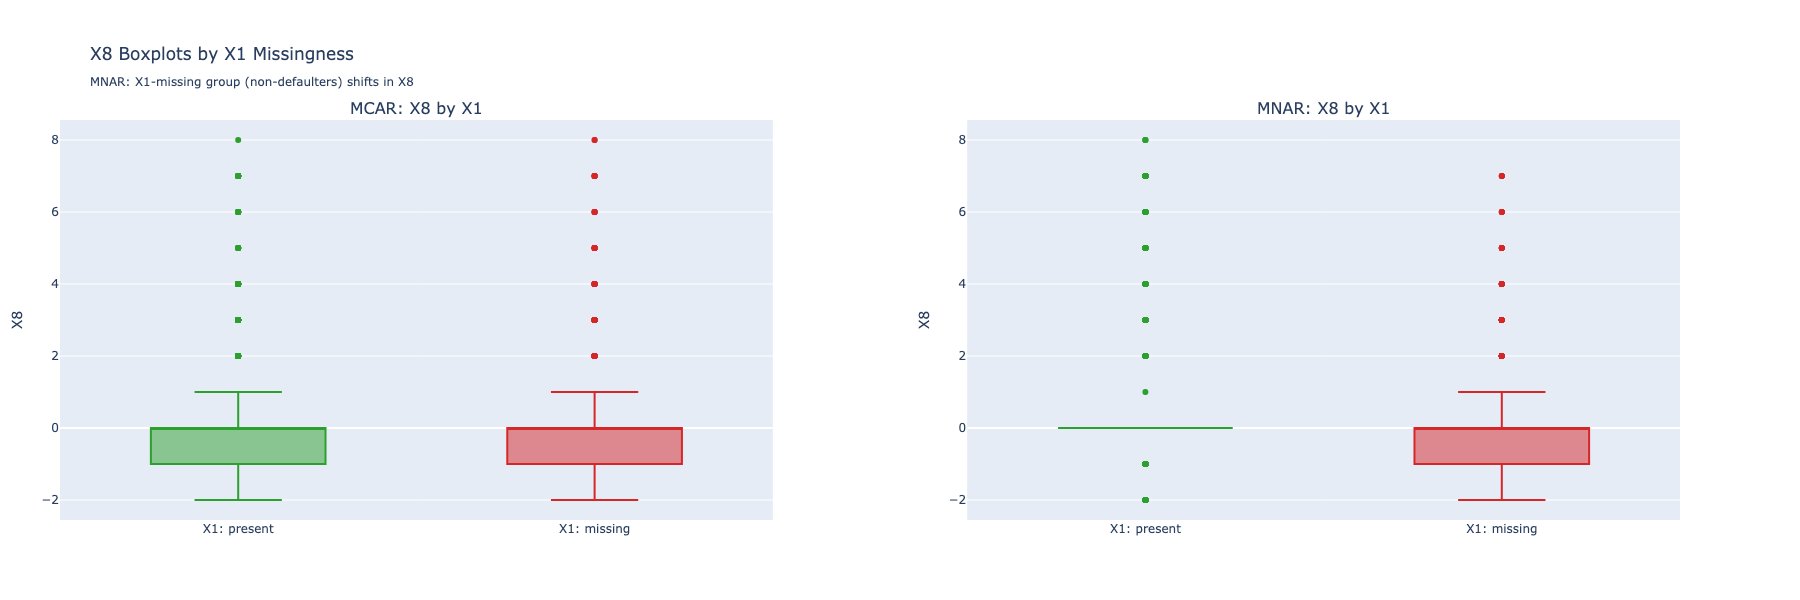

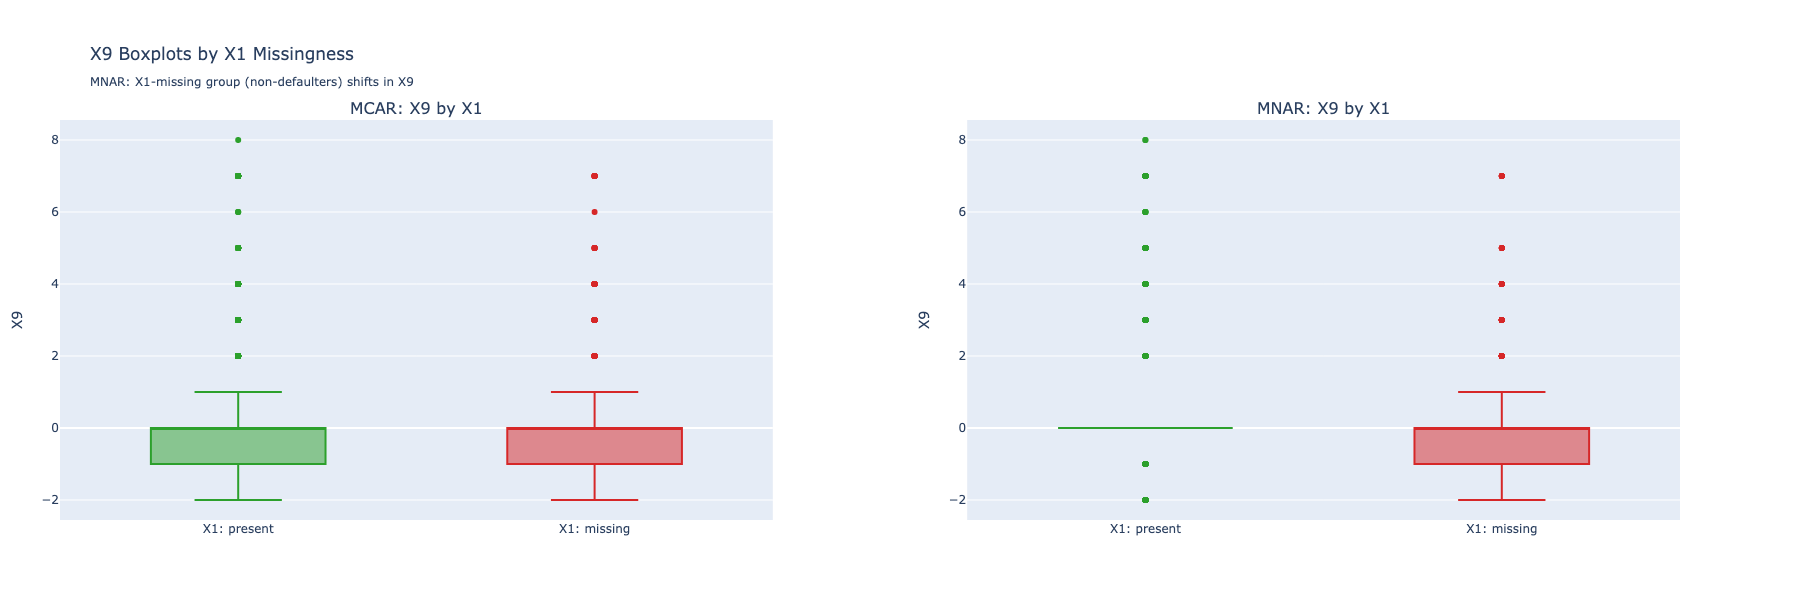

In [18]:
panel_x8 = Panel(
    plots=[
        md_mcar.boxplot(x="X8", color_by="X1", title="MCAR: X8 by X1"),
        md_mnar.boxplot(x="X8", color_by="X1", title="MNAR: X8 by X1"),
    ],
    title="X8 Boxplots by X1 Missingness",
    description="MNAR: X1-missing group (non-defaulters) shifts in X8",
    width=1800,
    height=600,
)

panel_x8.show()
panel_x8.save()

panel_x9 = Panel(
    plots=[
        md_mcar.boxplot(x="X9", color_by="X1", title="MCAR: X9 by X1"),
        md_mnar.boxplot(x="X9", color_by="X1", title="MNAR: X9 by X1"),
    ],
    title="X9 Boxplots by X1 Missingness",
    description="MNAR: X1-missing group (non-defaulters) shifts in X9",
    width=1800,
    height=600,
)

panel_x9.show()
panel_x9.save()

we now apply boxplot, density, and scatterplot to compare all three mechanisms using X9 (MAR driver + MNAR non-affected proxy) and X5 (MAR partner + MNAR affected).

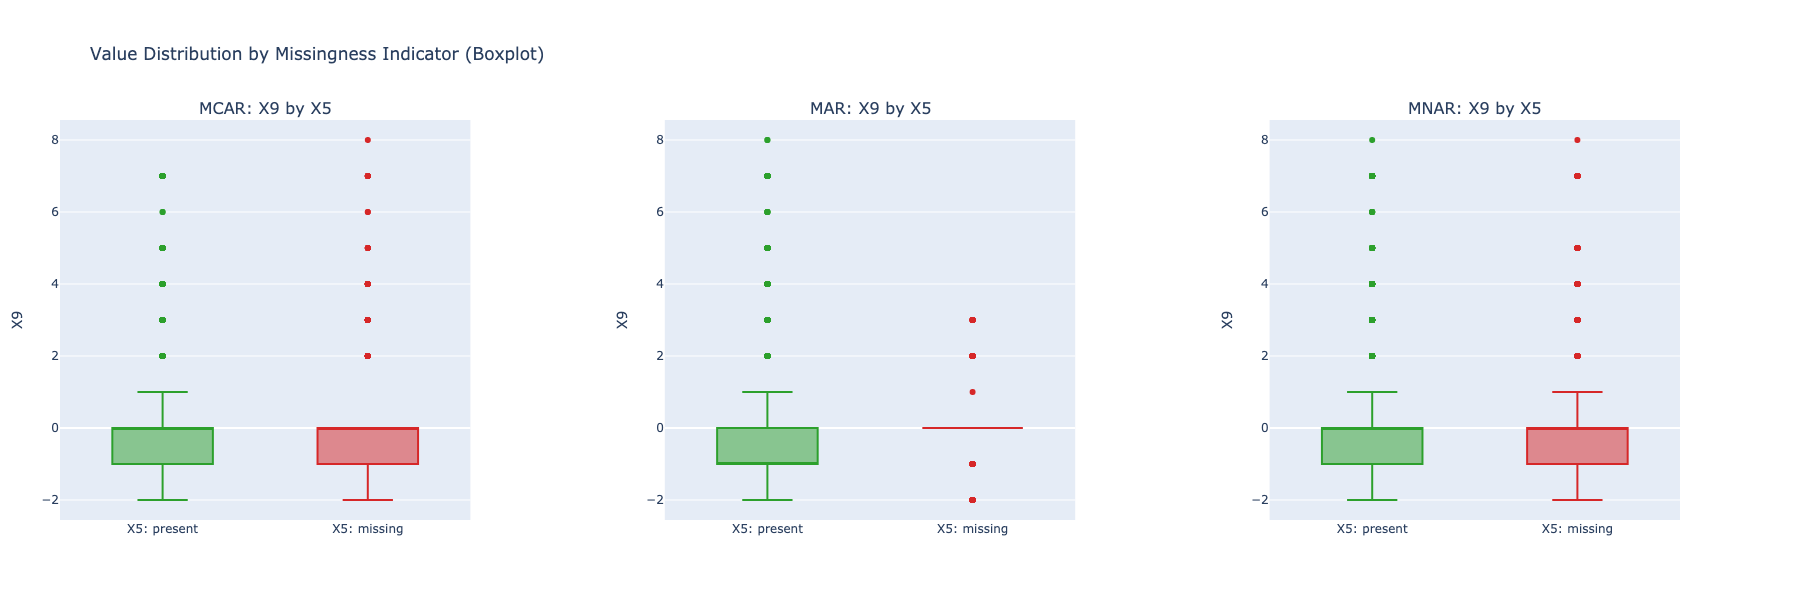

In [19]:
panel = Panel(
    plots=[
        md_mcar.boxplot(x="X9", color_by="X5", title="MCAR: X9 by X5"),
        md_mar.boxplot(x="X9", color_by="X5", title="MAR: X9 by X5"),
        md_mnar.boxplot(x="X9", color_by="X5", title="MNAR: X9 by X5"),
    ],
    title="Value Distribution by Missingness Indicator (Boxplot)",
    width=1800,
    height=600,
)

panel.show()
panel.save()

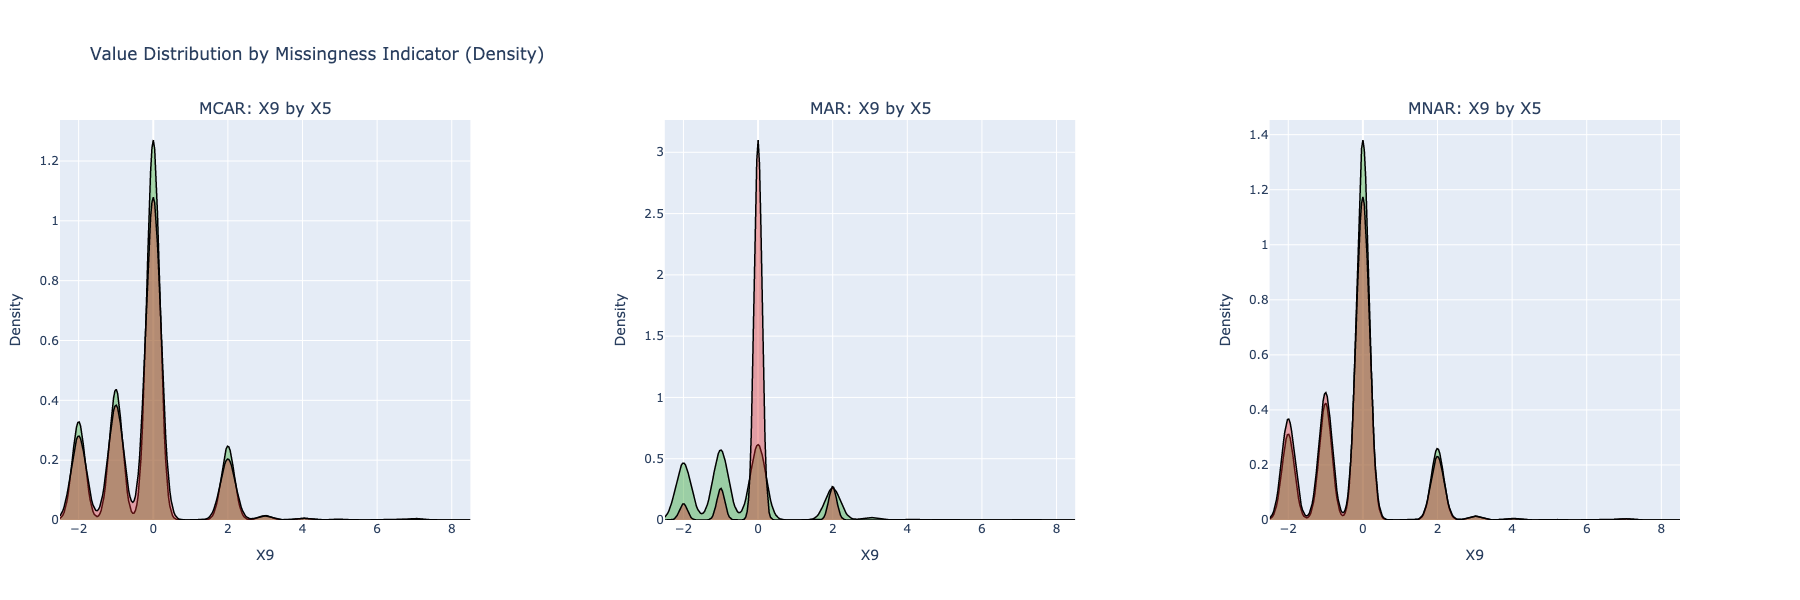

In [20]:
panel = Panel(
    plots=[
        md_mcar.density(x="X9", color_by="X5", title="MCAR: X9 by X5"),
        md_mar.density(x="X9", color_by="X5", title="MAR: X9 by X5"),
        md_mnar.density(x="X9", color_by="X5", title="MNAR: X9 by X5"),
    ],
    title="Value Distribution by Missingness Indicator (Density)",
    width=1800,
    height=600,
)

panel.show()
panel.save()

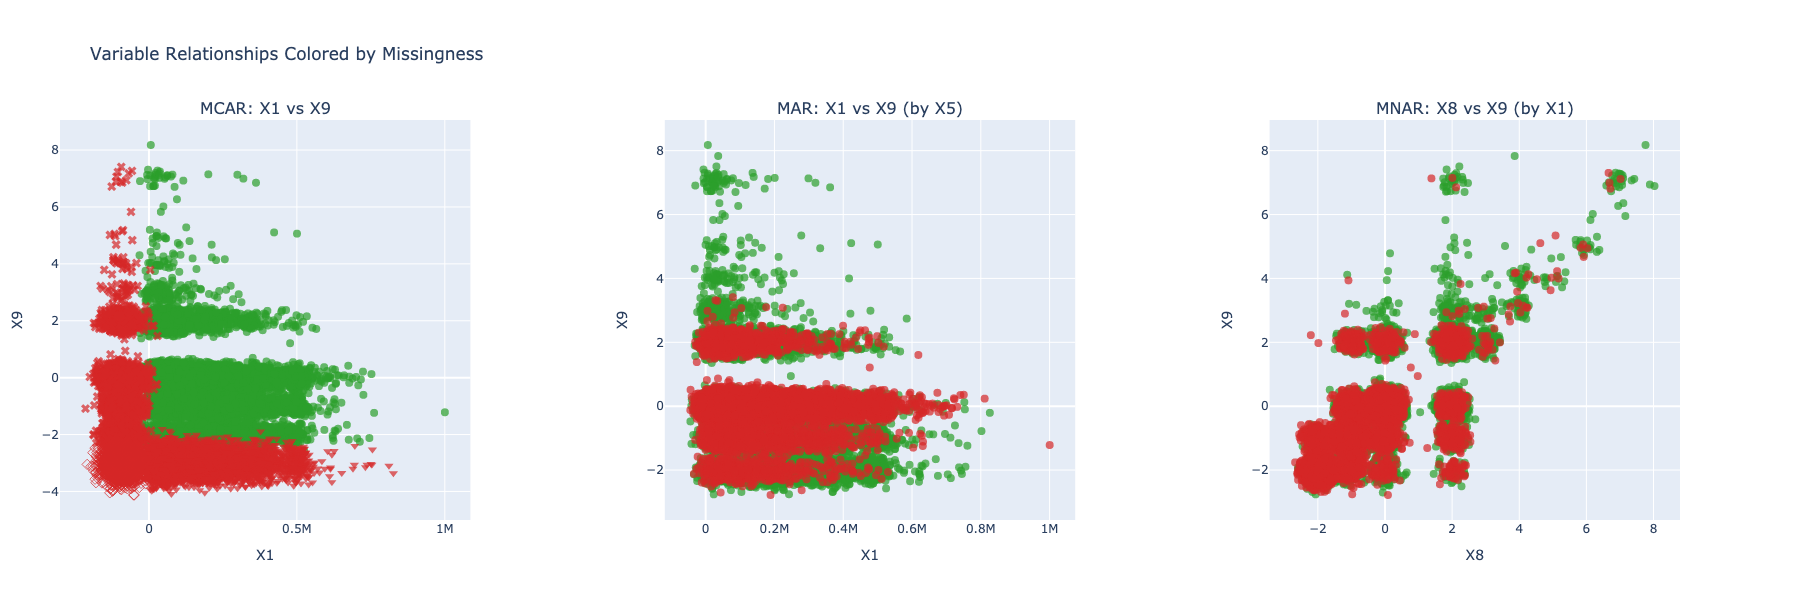

In [21]:
panel = Panel(
    plots=[
        md_mcar.scatterplot(x="X1", y="X9", title="MCAR: X1 vs X9"),
        md_mar.scatterplot(x="X1", y="X9", missingness_color_column="X5", title="MAR: X1 vs X9 (by X5)"),
        md_mnar.scatterplot(x="X8", y="X9", missingness_color_column="X1", title="MNAR: X8 vs X9 (by X1)"),
    ],
    title="Variable Relationships Colored by Missingness",
    width=1800,
    height=600,
)

panel.show()
panel.save()